<a href="https://colab.research.google.com/github/AnanyaJain2813/AnanyaJain2813/blob/main/Copy_of_IDS_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/data.csv')

data.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
data = data.dropna()
data = data[~data.isin([float('inf'), -float('inf')]).any(axis=1)]


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Clean column names by stripping whitespace
data.columns = data.columns.str.strip()

le = LabelEncoder()

# Check if 'Label' column exists before proceeding
if 'Label' in data.columns:
    data['Label'] = le.fit_transform(data['Label'])
else:
    print("Error: 'Label' column not found in the DataFrame. Available columns:")
    print(data.columns.tolist())

In [ ]:
data = data.select_dtypes(include=['number'])

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('Label', axis=1)
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9999778481713666
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19638
           1       1.00      1.00      1.00     25505

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



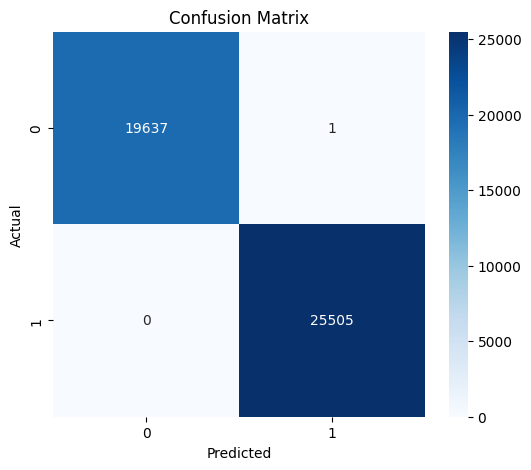

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

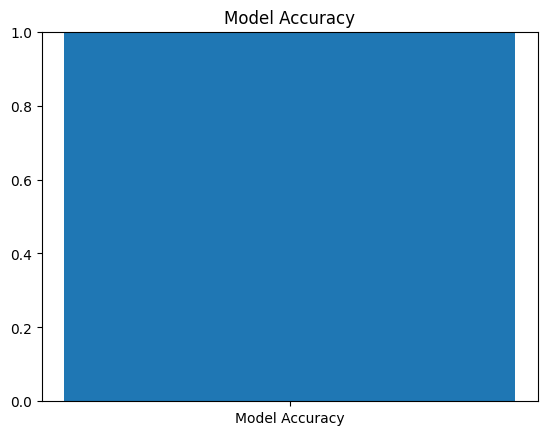

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

plt.bar(['Model Accuracy'], [accuracy])
plt.title("Model Accuracy")
plt.ylim(0,1)
plt.show()

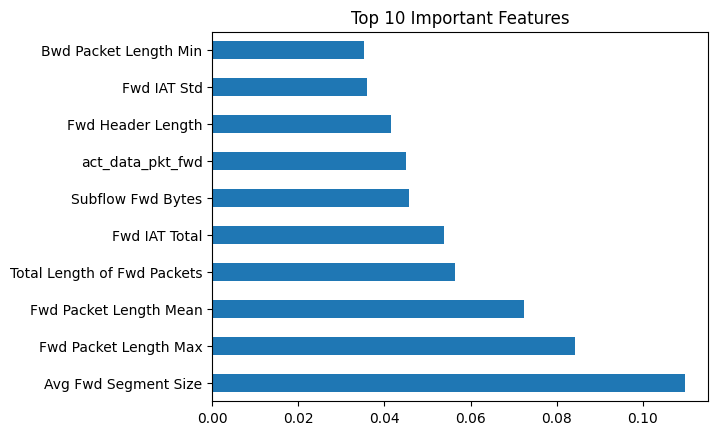

In [ ]:
import pandas as pd

importance = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

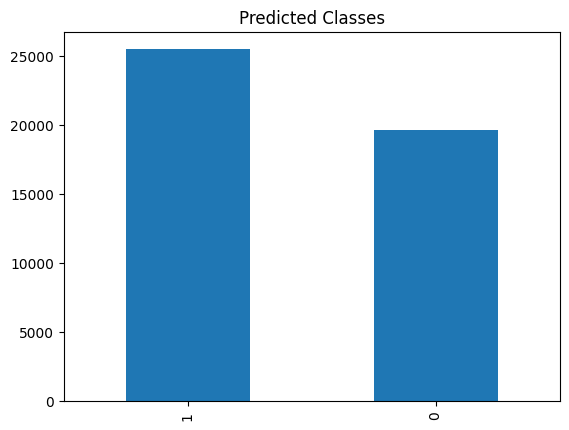

In [ ]:
import pandas as pd

pd.Series(y_pred).value_counts().plot(kind='bar')
plt.title("Predicted Classes")
plt.show()